# LightGBM Training With RMSLE Logging

Notebook tối giản để train LightGBM bằng bộ tham số tối ưu từ `notebooks/07_evaluation/LightGBM_training_v2_out.ipynb`, log eval set và plot RMSLE theo từng boosting round.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / "data" / "processed" / "splits").exists():
            return candidate
        nested = candidate / "Topic_13_Retail_Store_Sales_Time_Series"
        if (nested / "data" / "processed" / "splits").exists():
            return nested

    raise FileNotFoundError("Could not locate project root containing data/processed/splits")


BASE = find_project_root()
SPLIT_DIR = BASE / "data" / "processed" / "splits"

X_train = pd.read_csv(SPLIT_DIR / "train_features.csv")
y_train = pd.read_csv(SPLIT_DIR / "train_target.csv")
X_val = pd.read_csv(SPLIT_DIR / "val_features.csv")
y_val = pd.read_csv(SPLIT_DIR / "val_target.csv")
y_val_orig = pd.read_csv(SPLIT_DIR / "val_target_original.csv")

print(f"BASE: {BASE}")
print(f"X_train {X_train.shape} | X_val {X_val.shape}")


BASE: D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series
X_train (2918916, 49) | X_val (55242, 49)


In [3]:
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in object_cols:
    encoder = LabelEncoder()
    combined = pd.concat([X_train[col], X_val[col]], ignore_index=True).astype(str)
    encoder.fit(combined)

    X_train[col] = encoder.transform(X_train[col].astype(str)).astype(np.int32)
    X_val[col] = encoder.transform(X_val[col].astype(str)).astype(np.int32)
    label_encoders[col] = encoder

remaining_object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
if remaining_object_cols:
    raise ValueError(f"Still has object columns: {remaining_object_cols}")

print(f"Label encoded {len(object_cols)} columns")


Label encoded 6 columns


In [4]:
def rmsle_from_log_arrays(y_true_log, y_pred_log) -> float:
    y_true = np.clip(np.expm1(np.asarray(y_true_log)), 0, None)
    y_pred = np.clip(np.expm1(np.asarray(y_pred_log)), 0, None)
    return float(np.sqrt(mean_squared_log_error(y_true, y_pred)))


def final_val_summary(model_name: str, val_pred_log) -> pd.DataFrame:
    summary = pd.DataFrame(
        {
            "model": [model_name],
            "val_rmsle": [rmsle_from_log_arrays(y_val["sales_log"], val_pred_log)],
            "best_round": [int(history.loc[history["val_rmsle"].idxmin(), "round"])],
            "best_val_rmsle": [float(history["val_rmsle"].min())],
        }
    )
    return summary


def plot_history(model_name: str) -> None:
    plt.figure(figsize=(12, 5))
    plt.plot(history["round"], history["train_rmsle"], label="Train RMSLE", linewidth=2)
    plt.plot(history["round"], history["val_rmsle"], label="Validation RMSLE", linewidth=2)
    best_idx = history["val_rmsle"].idxmin()
    plt.scatter(
        history.loc[best_idx, "round"],
        history.loc[best_idx, "val_rmsle"],
        color="crimson",
        s=60,
        label=f"Best val round = {int(history.loc[best_idx, 'round'])}",
        zorder=3,
    )
    plt.title(f"{model_name} RMSLE by Boosting Round")
    plt.xlabel("Boosting round")
    plt.ylabel("RMSLE")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
import lightgbm as lgb


def lgb_rmsle_metric(y_true_log, y_pred_log):
    return "rmsle", rmsle_from_log_arrays(y_true_log, y_pred_log), False


best_params = {
    "n_estimators": 1000,
    "learning_rate": 0.03452197544347247,
    "num_leaves": 209,
    "min_child_samples": 199,
    "subsample": 0.9044243675990947,
    "colsample_bytree": 0.6878203016641873,
    "reg_alpha": 0.0010446251525877439,
    "reg_lambda": 0.0037601083080145018,
    "objective": "regression",
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

model = lgb.LGBMRegressor(**best_params)
model.fit(
    X_train,
    y_train["sales_log"],
    eval_set=[(X_train, y_train["sales_log"]), (X_val, y_val["sales_log"])],
    eval_names=["train", "val"],
    eval_metric=lgb_rmsle_metric,
    callbacks=[lgb.log_evaluation(period=100)],
)


[100]	train's l2: 0.162616	train's rmsle: 0.403226	val's l2: 0.150451	val's rmsle: 0.38788
[200]	train's l2: 0.139287	train's rmsle: 0.37298	val's l2: 0.140753	val's rmsle: 0.37517
[300]	train's l2: 0.132831	train's rmsle: 0.364158	val's l2: 0.139133	val's rmsle: 0.373
[400]	train's l2: 0.129492	train's rmsle: 0.359546	val's l2: 0.138266	val's rmsle: 0.371827
[500]	train's l2: 0.127074	train's rmsle: 0.356161	val's l2: 0.137855	val's rmsle: 0.371269
[600]	train's l2: 0.125203	train's rmsle: 0.353528	val's l2: 0.137552	val's rmsle: 0.370857
[700]	train's l2: 0.123491	train's rmsle: 0.351094	val's l2: 0.137327	val's rmsle: 0.37055
[800]	train's l2: 0.12189	train's rmsle: 0.3488	val's l2: 0.137161	val's rmsle: 0.370319
[900]	train's l2: 0.120635	train's rmsle: 0.346997	val's l2: 0.137027	val's rmsle: 0.370135
[1000]	train's l2: 0.119444	train's rmsle: 0.345275	val's l2: 0.136951	val's rmsle: 0.370031


LGBMRegressor(colsample_bytree=0.6878203016641873,
              learning_rate=0.03452197544347247, min_child_samples=199,
              n_estimators=1000, n_jobs=-1, num_leaves=209,
              objective='regression', random_state=42,
              reg_alpha=0.0010446251525877439, reg_lambda=0.0037601083080145018,
              subsample=0.9044243675990947, verbose=-1)

In [6]:
results = model.evals_result_

history = pd.DataFrame(
    {
        "round": np.arange(1, len(results["train"]["rmsle"]) + 1),
        "train_rmsle": results["train"]["rmsle"],
        "val_rmsle": results["val"]["rmsle"],
    }
)

history.head()


,round,train_rmsle,val_rmsle
0,1,2.606812,2.553492
1,2,2.519960,2.467816
2,3,2.436080,2.385341
3,4,2.355211,2.305691
4,5,2.277318,2.228896


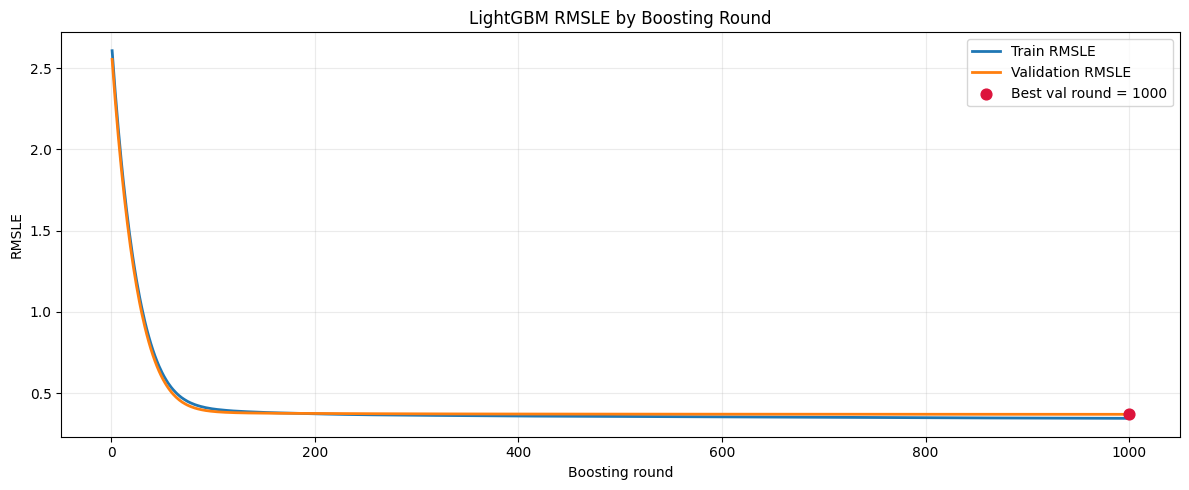

,model,val_rmsle,best_round,best_val_rmsle
0,LightGBM,0.370031,1000,0.370031


In [7]:
plot_history("LightGBM")

val_pred_log = model.predict(X_val)
summary = final_val_summary("LightGBM", val_pred_log)
summary
